In [272]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [273]:
#save crap
GEN_PATH = "../../assets/05/gen/"

#CANVAS DEF
WIDTH = 600
HEIGHT = 400

BLACK = [0, 0, 0]
WHITE = [255, 255, 255]
hlines = [[] for _ in range(HEIGHT)]
#canvas pixel array. WIDTH, HEIGHT RGB, WHITE CANVAS. 8 bits unsigned
canvas = np.full((HEIGHT, WIDTH, 3), 255, dtype = np.uint8)

In [274]:
#BRESENHAM'S LINE ALGORITHM

def lineHBresenham(x0, y0, x1, y1, draw):
    dx = x1 - x0
    dy = y1 - y0

    ydir = 1 if y1 > y0 else -1

    dy *= ydir

    y = y0
    D = 2 * dy - dx
 
    for x in range(x0, x1 + 1):
        if draw:
            canvas[y, x] = BLACK
        else:
            if y != y1:
                hlines[y].append(x)

        if D >= 0:
            y += ydir
            D -= 2 * dx
        D += 2 * dy


def lineVBresenham(x0, y0, x1, y1, draw):
    dx = x1 - x0
    dy = y1 - y0

    xdir = 1 if x1 > x0 else -1

    dx *= xdir

    x = x0
    D = 2 * dx - dy
    for y in range(y0, y1 + 1):
        if draw:
            canvas[y, x] = BLACK
        else:
            if y != y1:
                hlines[y].append(x)

        if D >= 0:
            x += xdir
            D -= 2 * dy
        D += 2 * dx

def lineBresenham(x0, y0, x1, y1, draw):
    dx = x1 - x0
    dy = y1 - y0
  
    if not draw and dy == 0:
        return
  
    if dx == 0 and dy == 0:
        #point
        if draw:
            canvas[y0, x0] = BLACK; 
            return
        else:
            hlines[y0].append(x0) 
    
    adx = abs(dx)
    ady = abs(dy)
  
  
    if adx > ady:
        if x1 > x0:
            lineHBresenham(x0, y0, x1, y1, draw)
        else:
            lineHBresenham(x1, y1, x0, y0, draw)
    else:
        if y1 > y0:
            lineVBresenham(x0, y0, x1, y1, draw)
        else: 
            lineVBresenham(x1, y1, x0, y0, draw)

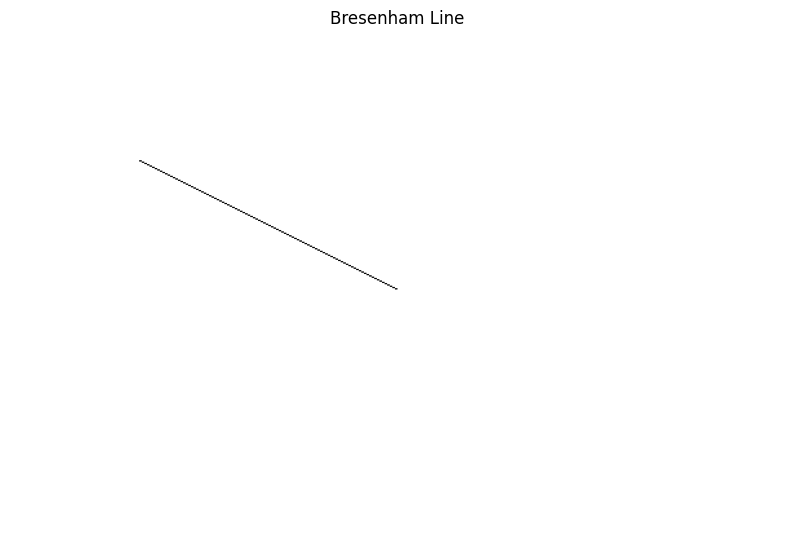

In [275]:
#BRESENHAM LINE DRAW. EZ.
canvas[:, :, :] = WHITE
v = (100, 100)
w = (WIDTH / 2 - 1, HEIGHT / 2 - 1)

lineBresenham(int(v[0]), int(v[1]), int(w[0]), int(w[1]), True)

plt.figure(figsize = (10, 8))
plt.imshow(canvas) 
plt.title("Bresenham Line")
plt.axis("off")
plt.savefig(f"{GEN_PATH}bresenham_line.png")
plt.show()

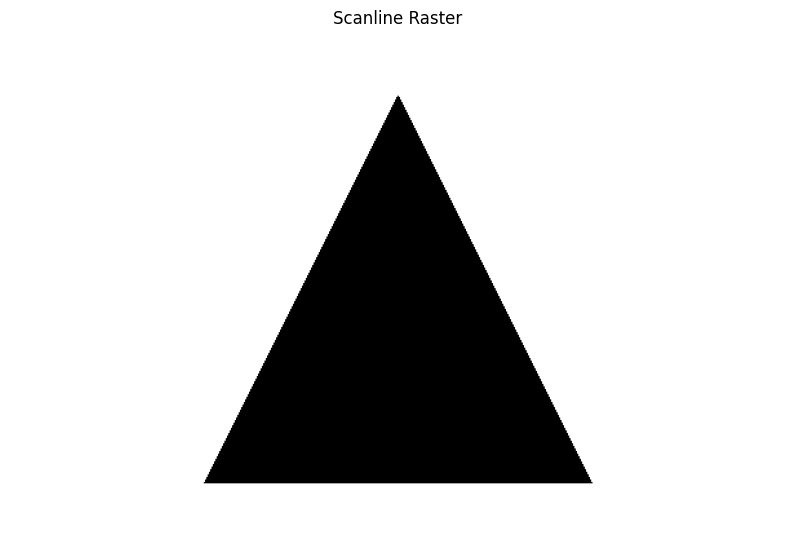

In [276]:
#SCANLINE RASTER. POLYGON FILLING. BRESEHNHAM EDGE CASE.
#VERTICES. CONVEX POLYGON.
canvas[:, :, :] = WHITE
hlines = [[] for _ in range(HEIGHT)]

v1 = (300, 50)
v2 = (150, 350)
v3 = (450, 350)
polygon = [v1, v2, v3]

#SET BOUNDARIES, FILL LINE HEIGHT LIST. TOP DOWN SCANLINE.
#First PASS. NO DRAW.
sz = len(polygon)
for i in range(sz):
    lineBresenham(int(polygon[i % sz][0]), int(polygon[i % sz][1]), int(polygon[(i + 1) % sz][0]), int(polygon[(i + 1) % sz][1]), False)




#DRAW POLYGON
for y in range(HEIGHT):

    xvals = hlines[y]
    xvals.sort()
        
    sz = len(xvals)

    for i in range(0, sz, 2):
        if i + 1 < sz:
            lineBresenham(xvals[i], y, xvals[i + 1], y, True)

plt.figure(figsize = (10, 8))
plt.imshow(canvas) 
plt.title("Scanline Raster")
plt.axis("off")
plt.savefig(f"{GEN_PATH}scanline_triangle.png")
plt.show()

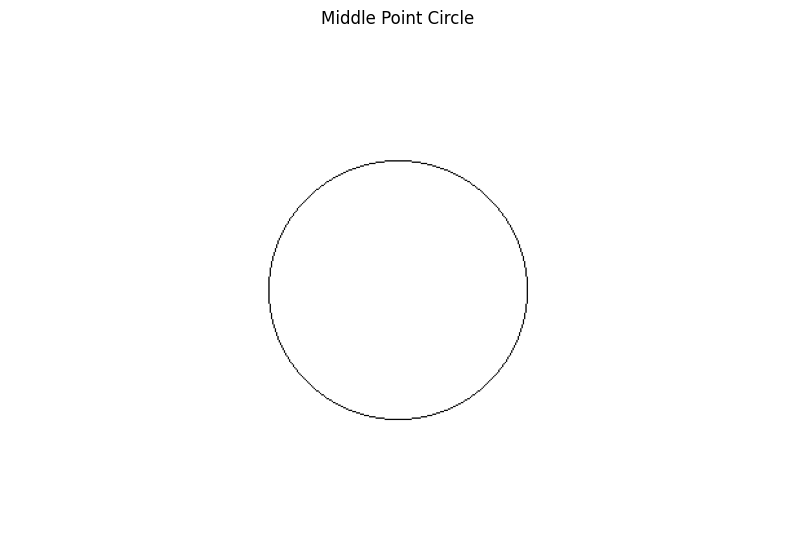

In [277]:
#MIDDLE POINT CIRCLE
canvas[:, :, :] = WHITE
#init vars. Center (0, 0) radius 6.
def set_pixel_circle(x0, y0, x, y):
    boundary = [
                    (x + x0, y + y0), (-x + x0, y + y0), 
                    (x + x0, -y + y0), (-x + x0, -y + y0),
                    (y + x0, x + y0), (-y + x0, x + y0), 
                    (y + x0, -x + y0), (-y + x0, -x + y0)
               ]
    
    for bx, by in boundary:
        canvas[by, bx] = BLACK


#CIRCLE DRAW
x0 = WIDTH // 2
y0 = HEIGHT // 2
r = 100


#INITIALIZATION
x = 0
y = r
D = 5 - 4 * r

set_pixel_circle(x0, y0, x, y)

while x < y:
    x += 1
    set_pixel_circle(x0, y0, x, y)
    if D <= 0:
        D += 8 * x + 12
    else:
        D += 8 * (x - y) + 20
        y -= 1
        
plt.figure(figsize = (10, 8))
plt.imshow(canvas) 
plt.title("Middle Point Circle")
plt.axis("off")
plt.savefig(f"{GEN_PATH}middle_point_circle.png")
plt.show()